<a href="https://colab.research.google.com/github/shrivastavay882-glitch/Weather-Data-Analysis/blob/main/weather_report_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               1096 non-null   object 
 1   Temperature_C      1093 non-null   float64
 2   Humidity_Percent   1093 non-null   float64
 3   Precipitation_mm   1093 non-null   float64
 4   Season             1096 non-null   object 
 5   Weather_Condition  1096 non-null   object 
dtypes: float64(3), object(3)
memory usage: 51.5+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 1087 entries, 0 to 1095
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               1087 non-null   datetime64[ns]
 1   Temperature_C      1087 non-null   float64       
 2   Humidity_Percent   1087 non-null   float64       
 3   Precipitation_mm   1087 non-null   float64       
 4   Season             10

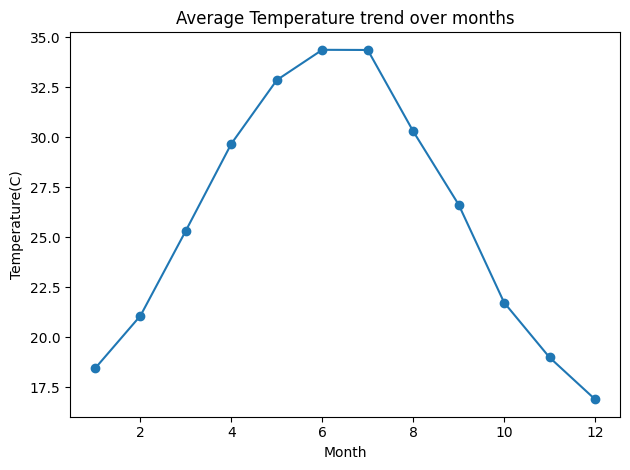

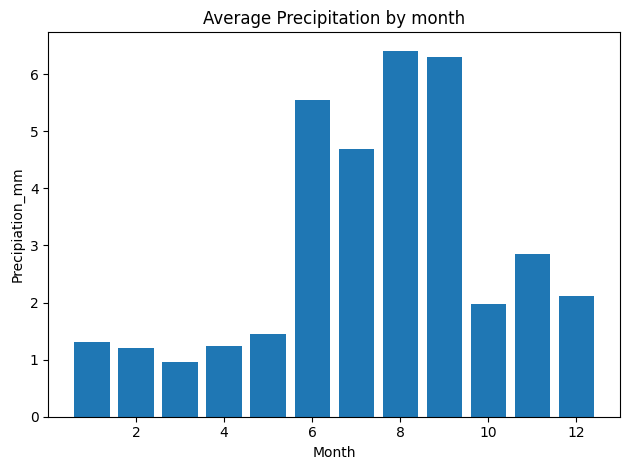

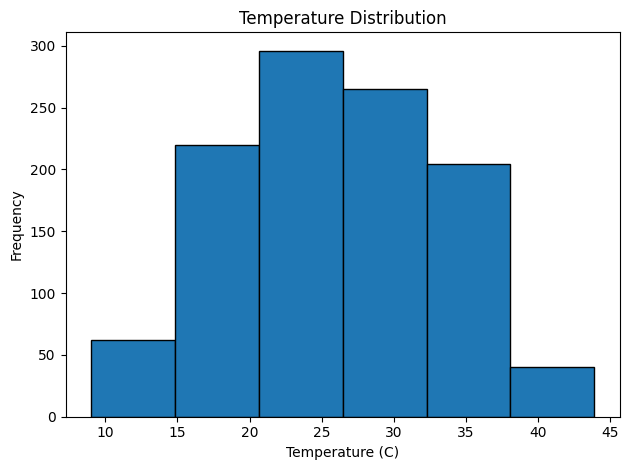

          Date  Temperature_C  Humidity_Percent  Precipitation_mm   Season  \
139 2023-05-20           43.9              55.7               0.0   Summer   
162 2023-06-12           42.4              85.9               0.0  Monsoon   
506 2024-05-21           42.4              72.1               0.0   Summer   
846 2025-04-26           42.4              52.2               0.0   Summer   
905 2025-06-24           42.2              66.7               0.0  Monsoon   

    Weather_Condition  
139               Hot  
162               Hot  
506               Hot  
846               Hot  
905               Hot  
          Date  Temperature_C  Humidity_Percent  Precipitation_mm  \
165 2023-06-15           31.8              72.8             49.21   
595 2024-08-18           29.2              59.4             48.65   
317 2023-11-14           16.2              65.1             48.10   
956 2025-08-14           29.6              81.3             39.50   
676 2024-11-07           27.6             

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data Cleaning
df = pd.read_csv('/content/weather_historical_data (1).csv')
df.info()
df.head()
df['Date'] = pd.to_datetime(df['Date'])  #changed the datatype from object to datetime
df.isnull().sum()                        # checked the total null or missing values

df = df.dropna()                         # dropped the null values
df.info()

print(df.describe().round(2))

# Descriptive Statistics for Temperature,Humidity and Precipitation
## Temperature Statistics
temp_mean = np.mean(df['Temperature_C'])
temp_median = np.median(df['Temperature_C'])
temp_std = np.std(df['Temperature_C'])

print("Mean Temperature:",temp_mean)
print("Median Temperature:",temp_median)
print("Standard Deviation Temperature:",temp_std)


## Humidity Statistics
humid_mean = np.mean(df['Humidity_Percent'])
humid_median = np.median(df['Humidity_Percent'])
humid_std = np.std(df['Humidity_Percent'])

print("Mean Humidity:",humid_mean)
print("Median Humidity:",humid_median)
print("Standard deviation Humidity:",humid_std)

## Precipitation Statistics
precip_mean = np.mean(df['Precipitation_mm'])
precip_median = np.median(df['Precipitation_mm'])
precip_std = np.std(df['Precipitation_mm'])

print("Mean Precipitation:",precip_mean)
print("Median Precipitation:",precip_median)
print("Standard Deviation for Precipitation:",precip_std)

# Monthly and Seasonal Analysis(Using Pandas Groupby)
Monthly_Summary = df.groupby(df['Date'].dt.month)[['Temperature_C','Precipitation_mm']].mean()
Seasonal_Summary = df.groupby('Season')[['Temperature_C','Precipitation_mm']].mean()
print('Monthly_Summary','\n',Monthly_Summary)
print('Seasonal_Summary' ,'\n',Seasonal_Summary)

# Visualization using Matplotlib
## Line chart showing average temperature trend over months
plt.plot(Monthly_Summary.index , Monthly_Summary['Temperature_C'],marker = 'o')
plt.xlabel('Month')
plt.ylabel('Temperature(C)')
plt.title('Average Temperature trend over months')
plt.tight_layout()
plt.show()

##Bar Plot:  total or average precipitation by month
plt.bar(Monthly_Summary.index , Monthly_Summary['Precipitation_mm'])
plt.xlabel('Month')
plt.ylabel('Precipiation_mm')
plt.title('Average Precipitation by month')
plt.tight_layout()
plt.show()

## Histogram: Show temperature distribution
plt.hist(df['Temperature_C'],bins=6,edgecolor ='black')
plt.xlabel('Temperature (C)')
plt.ylabel('Frequency')
plt.title('Temperature Distribution')
plt.tight_layout()
plt.show()


#Identifying Extreme Weather
## Extreme Temperature
threshold_Temperature = np.percentile(df['Temperature_C'],95)
extreme_temperature = df[df['Temperature_C']>threshold_Temperature]
print(extreme_temperature.sort_values(by ='Temperature_C',ascending=False).head())
## Extreme Precipitation
Threshold_Precipitation = np.percentile(df['Precipitation_mm'],95)
Extreme_Precipitation = df[df['Precipitation_mm']>Threshold_Precipitation]
print(Extreme_Precipitation.sort_values(by ='Precipitation_mm',ascending=False).head())